# Object Detection with YOLOv11

**Dataset:** Alien vs Predator — 347 train / 100 val images per class  
**Task:** Fine-tune YOLOv11 for 2-class object detection


In [1]:
!pip install ultralytics gdown

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 65.3 MB/s eta 0:00:0000:010:01m
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you 

In [2]:
import os
import shutil
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import yaml

In [6]:
DATA_ROOT = Path("/kaggle/input/datasets/pmigdal/alien-vs-predator-images/data")
YOLO_ROOT = Path("/kaggle/working/yolo_pseudobox_dataset")
CLASSES = ["alien", "predator"]

for split in ("train", "validation"):
    for cls in CLASSES:
        imgs = list((DATA_ROOT / split / cls).glob("*.jpg"))
        print(f"{split:>10} / {cls:<10}: {len(imgs)} images")

     train / alien     : 347 images
     train / predator  : 347 images
validation / alien     : 100 images
validation / predator  : 100 images


## Sample Images


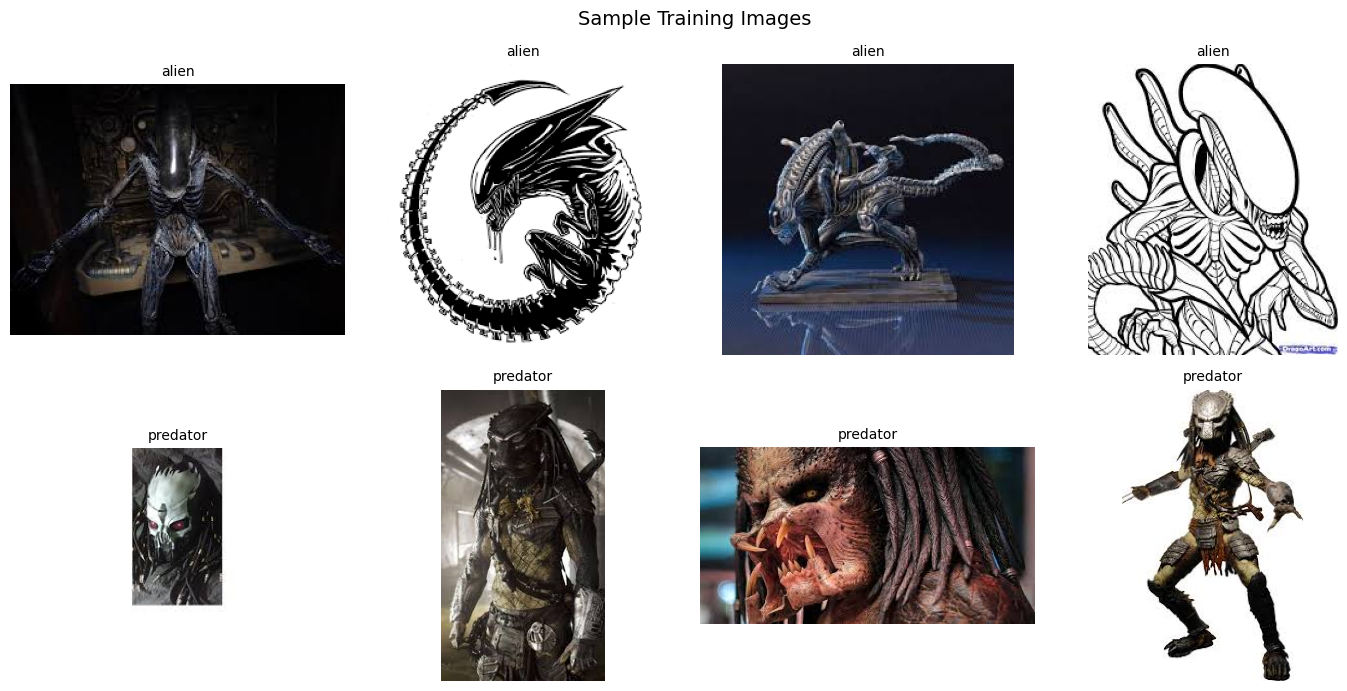

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Sample Training Images", fontsize=14)

for row, cls in enumerate(CLASSES):
    imgs = list((DATA_ROOT / "train" / cls).glob("*.jpg"))
    samples = random.sample(imgs, 4)
    for col, path in enumerate(samples):
        img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls, fontsize=10)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## Convert to YOLO Detection Format with Pseudo Bounding Boxes

The original dataset only has image-level labels (`alien/` and `predator/`). YOLO detection needs bounding boxes, but using `0.5 0.5 1.0 1.0` makes every object equal to the whole image, so the model does not learn localization.

This notebook now creates **pseudo bounding boxes** automatically:

1. `GrabCut` estimates the foreground object.
2. If GrabCut fails, an edge-based fallback estimates the content box.
3. The box is saved in YOLO format: `class_id cx cy w h`.
4. Synthetic collage images are generated so YOLO sees multiple objects in one image, similar to the screenshot test.

This is still weaker than manual labels, but it is a better automatic method than full-image boxes.


In [32]:
for split in ("train", "val"):
    (YOLO_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

SPLIT_MAP = {"train": "train", "validation": "val"}
IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp"}


def list_images(folder):
    return sorted([p for p in Path(folder).iterdir() if p.suffix.lower() in IMG_EXTS])


def clamp_box(x1, y1, x2, y2, w, h):
    x1 = int(np.clip(x1, 0, w - 1))
    y1 = int(np.clip(y1, 0, h - 1))
    x2 = int(np.clip(x2, x1 + 1, w))
    y2 = int(np.clip(y2, y1 + 1, h))
    return x1, y1, x2, y2


def yolo_line(cls_id, box, w, h):
    x1, y1, x2, y2 = box
    cx = ((x1 + x2) / 2) / w
    cy = ((y1 + y2) / 2) / h
    bw = (x2 - x1) / w
    bh = (y2 - y1) / h
    return f"{cls_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n"


def largest_component_box(mask, min_area_ratio=0.01):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), 8)
    if num_labels <= 1:
        return None

    h, w = mask.shape[:2]
    min_area = min_area_ratio * w * h
    candidates = []
    for label_id in range(1, num_labels):
        x, y, bw, bh, area = stats[label_id]
        if area >= min_area:
            candidates.append((area, x, y, x + bw, y + bh))

    if not candidates:
        return None

    _, x1, y1, x2, y2 = max(candidates, key=lambda item: item[0])
    return clamp_box(x1, y1, x2, y2, w, h)


def edge_fallback_box(img):
    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(gray, 50, 150)
    kernel = np.ones((7, 7), np.uint8)
    mask = cv2.dilate(edges, kernel, iterations=2)
    box = largest_component_box(mask, min_area_ratio=0.005)

    if box is None:
        margin_x = int(0.08 * w)
        margin_y = int(0.08 * h)
        return clamp_box(margin_x, margin_y, w - margin_x, h - margin_y, w, h)

    x1, y1, x2, y2 = box
    pad_x = int(0.04 * w)
    pad_y = int(0.04 * h)
    return clamp_box(x1 - pad_x, y1 - pad_y, x2 + pad_x, y2 + pad_y, w, h)


def estimate_object_box(img):
    """Estimate a foreground bounding box without manual annotations."""
    h, w = img.shape[:2]
    if h < 20 or w < 20:
        return 0, 0, w, h

    margin_x = max(2, int(0.04 * w))
    margin_y = max(2, int(0.04 * h))
    rect = (margin_x, margin_y, max(1, w - 2 * margin_x), max(1, h - 2 * margin_y))

    mask = np.zeros((h, w), np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    try:
        cv2.grabCut(img, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)
        fg = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 255, 0).astype("uint8")
        kernel = np.ones((5, 5), np.uint8)
        fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, kernel, iterations=1)
        fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kernel, iterations=2)
        box = largest_component_box(fg, min_area_ratio=0.01)
    except cv2.error:
        box = None

    if box is None:
        return edge_fallback_box(img)

    x1, y1, x2, y2 = box
    area_ratio = ((x2 - x1) * (y2 - y1)) / (w * h)

    # If the estimated mask is basically the whole image, use the edge fallback.
    if area_ratio > 0.90 or area_ratio < 0.01:
        return edge_fallback_box(img)

    pad_x = int(0.03 * w)
    pad_y = int(0.03 * h)
    return clamp_box(x1 - pad_x, y1 - pad_y, x2 + pad_x, y2 + pad_y, w, h)


def convert_original_dataset():
    for src_split, dst_split in SPLIT_MAP.items():
        for cls_id, cls_name in enumerate(CLASSES):
            src_dir = DATA_ROOT / src_split / cls_name
            img_dst = YOLO_ROOT / "images" / dst_split
            lbl_dst = YOLO_ROOT / "labels" / dst_split
            img_dst.mkdir(parents=True, exist_ok=True)
            lbl_dst.mkdir(parents=True, exist_ok=True)

            for img_path in list_images(src_dir):
                img = cv2.imread(str(img_path))
                if img is None:
                    continue

                h, w = img.shape[:2]
                box = estimate_object_box(img)
                new_name = f"{cls_name}_{img_path.stem}{img_path.suffix.lower()}"
                shutil.copy(img_path, img_dst / new_name)
                (lbl_dst / f"{Path(new_name).stem}.txt").write_text(yolo_line(cls_id, box, w, h))


convert_original_dataset()

print("Converted dataset with pseudo boxes:")
for dst_split in ("train", "val"):
    n_img = len(list((YOLO_ROOT / "images" / dst_split).glob("*.*")))
    n_lbl = len(list((YOLO_ROOT / "labels" / dst_split).glob("*.txt")))
    print(f"  {dst_split}: {n_img} images, {n_lbl} labels")


Converted dataset with pseudo boxes:
  train: 694 images, 694 labels
  val: 200 images, 200 labels


## Check Pseudo Boxes

Always inspect generated boxes before training. If many boxes look bad, automatic pseudo-labeling is not enough and manual labels are needed.


Train images found: 694


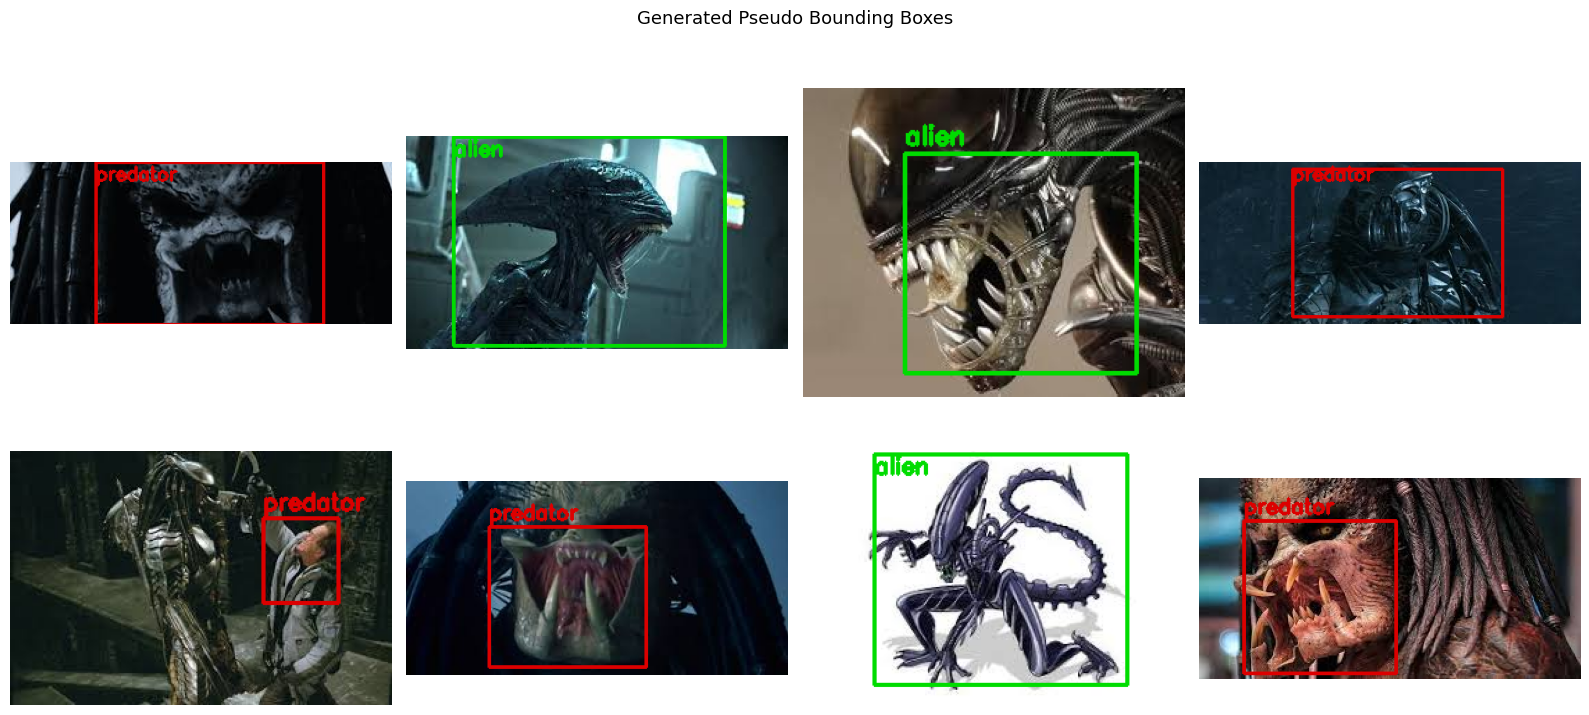

In [37]:
def read_yolo_labels(label_path, w, h):
    boxes = []

    for line in Path(label_path).read_text().strip().splitlines():
        parts = line.split()

        if len(parts) != 5:
            continue

        cls_id = int(parts[0])
        cx, cy, bw, bh = map(float, parts[1:])

        x1 = int((cx - bw / 2) * w)
        y1 = int((cy - bh / 2) * h)
        x2 = int((cx + bw / 2) * w)
        y2 = int((cy + bh / 2) * h)

        boxes.append((cls_id, clamp_box(x1, y1, x2, y2, w, h)))

    return boxes

train_imgs = list((YOLO_ROOT / "images" / "train").glob("*.*"))
print("Train images found:", len(train_imgs))

if len(train_imgs) == 0:
    print("No images found.")
else:
    preview_imgs = random.sample(train_imgs, min(8, len(train_imgs)))

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle("Generated Pseudo Bounding Boxes", fontsize=13)

    axes = list(axes.flat)

    for ax in axes:
        ax.axis("off")

    for ax, img_path in zip(axes, preview_imgs):
        img_bgr = cv2.imread(str(img_path))

        if img_bgr is None:
            print("Could not read:", img_path)
            continue

        img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        label_path = YOLO_ROOT / "labels" / "train" / f"{img_path.stem}.txt"
        boxes = read_yolo_labels(label_path, w, h)

        #print(img_path.name, "boxes:", len(boxes))

        for cls_id, (x1, y1, x2, y2) in boxes:
            color = (0, 220, 0) if CLASSES[cls_id] == "alien" else (220, 0, 0)

            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(
                img,
                CLASSES[cls_id],
                (x1, max(16, y1 - 6)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                color,
                2
            )

        ax.imshow(img)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## Synthetic Collage Augmentation

The screenshot contains many small images in one large canvas. The original dataset mostly has one centered subject per image. To bridge that gap, this cell creates synthetic images by pasting several alien/predator crops into one canvas and writing the real paste positions as YOLO labels.


In [38]:
def crop_from_original(img_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    x1, y1, x2, y2 = estimate_object_box(img)
    crop = img[y1:y2, x1:x2]
    if crop.size == 0:
        return img
    return crop


def random_background(canvas_h, canvas_w):
    # Screenshot-like dark/neutral background with subtle blocks.
    bg_color = random.choice([(32, 34, 40), (245, 245, 245), (18, 24, 32), (55, 55, 60)])
    canvas = np.full((canvas_h, canvas_w, 3), bg_color, dtype=np.uint8)
    for _ in range(random.randint(8, 18)):
        x1 = random.randint(0, canvas_w - 40)
        y1 = random.randint(0, canvas_h - 40)
        x2 = min(canvas_w, x1 + random.randint(60, 220))
        y2 = min(canvas_h, y1 + random.randint(40, 160))
        block = random.randint(-25, 35)
        color = tuple(int(np.clip(c + block, 0, 255)) for c in bg_color)
        cv2.rectangle(canvas, (x1, y1), (x2, y2), color, -1)
    return canvas


def add_synthetic_collages(n_train=450, n_val=60, canvas_w=960, canvas_h=640):
    pools = {
        cls_name: list_images(DATA_ROOT / "train" / cls_name)
        for cls_name in CLASSES
    }

    for split, n_images in [("train", n_train), ("val", n_val)]:
        img_dst = YOLO_ROOT / "images" / split
        lbl_dst = YOLO_ROOT / "labels" / split
        img_dst.mkdir(parents=True, exist_ok=True)
        lbl_dst.mkdir(parents=True, exist_ok=True)

        for i in range(n_images):
            canvas = random_background(canvas_h, canvas_w)
            labels = []
            occupied = []
            n_objects = random.randint(2, 7)

            for _ in range(n_objects):
                cls_id = random.randrange(len(CLASSES))
                cls_name = CLASSES[cls_id]
                crop = crop_from_original(random.choice(pools[cls_name]))
                if crop is None:
                    continue

                ch, cw = crop.shape[:2]
                target_w = random.randint(90, 260)
                scale = target_w / max(1, cw)
                target_h = max(40, int(ch * scale))
                if target_h > canvas_h * 0.65:
                    target_h = int(canvas_h * 0.65)
                    target_w = max(40, int(cw * (target_h / max(1, ch))))

                resized = cv2.resize(crop, (target_w, target_h), interpolation=cv2.INTER_AREA)

                placed = False
                for _attempt in range(30):
                    x1 = random.randint(0, max(0, canvas_w - target_w - 1))
                    y1 = random.randint(0, max(0, canvas_h - target_h - 1))
                    x2, y2 = x1 + target_w, y1 + target_h

                    # Keep overlaps moderate so labels remain readable.
                    ok = True
                    for ox1, oy1, ox2, oy2 in occupied:
                        inter_w = max(0, min(x2, ox2) - max(x1, ox1))
                        inter_h = max(0, min(y2, oy2) - max(y1, oy1))
                        inter = inter_w * inter_h
                        area = target_w * target_h
                        if inter / area > 0.25:
                            ok = False
                            break
                    if ok:
                        placed = True
                        break

                if not placed:
                    continue

                canvas[y1:y2, x1:x2] = resized
                occupied.append((x1, y1, x2, y2))
                labels.append(yolo_line(cls_id, (x1, y1, x2, y2), canvas_w, canvas_h))

            if not labels:
                continue

            out_name = f"synthetic_{split}_{i:04d}.jpg"
            cv2.imwrite(str(img_dst / out_name), canvas)
            (lbl_dst / out_name.replace(".jpg", ".txt")).write_text("".join(labels))


add_synthetic_collages(n_train=50, n_val=30)

print("Dataset after synthetic collage augmentation:")
for split in ("train", "val"):
    n_img = len(list((YOLO_ROOT / "images" / split).glob("*.*")))
    n_lbl = len(list((YOLO_ROOT / "labels" / split).glob("*.txt")))
    print(f"  {split}: {n_img} images, {n_lbl} labels")


Dataset after synthetic collage augmentation:
  train: 744 images, 744 labels
  val: 230 images, 230 labels


## Preview Synthetic Training Images


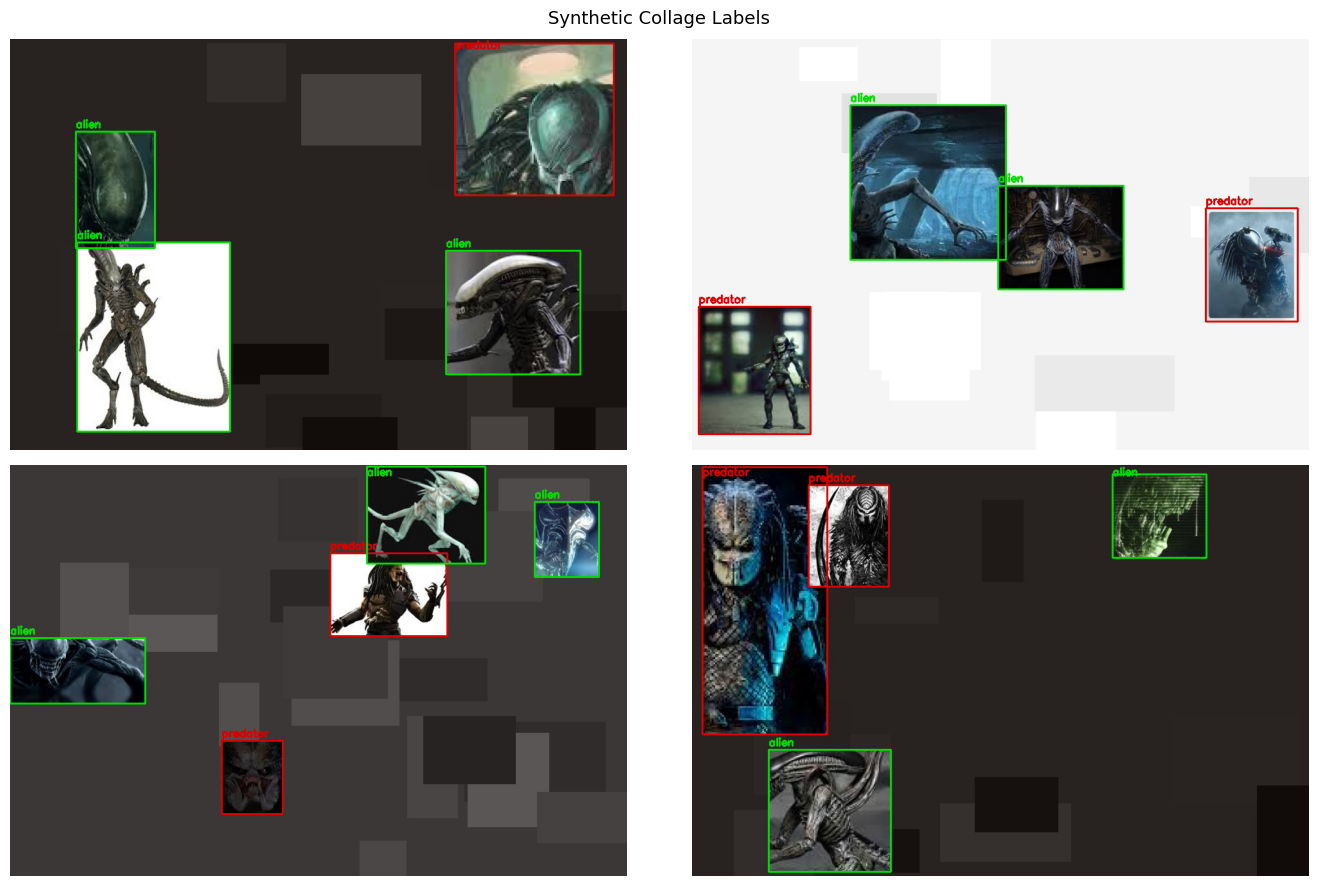

In [39]:
synthetic_imgs = sorted((YOLO_ROOT / "images" / "train").glob("synthetic_train_*.jpg"))
samples = random.sample(synthetic_imgs, min(4, len(synthetic_imgs)))
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Synthetic Collage Labels", fontsize=13)

for ax, img_path in zip(axes.flat, samples):
    img_bgr = cv2.imread(str(img_path))
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    label_path = YOLO_ROOT / "labels" / "train" / f"{img_path.stem}.txt"
    for line in label_path.read_text().strip().splitlines():
        cls_id, cx, cy, bw, bh = int(line.split()[0]), *map(float, line.split()[1:])
        x1 = int((cx - bw / 2) * w)
        y1 = int((cy - bh / 2) * h)
        x2 = int((cx + bw / 2) * w)
        y2 = int((cy + bh / 2) * h)
        color = (0, 220, 0) if CLASSES[cls_id] == "alien" else (220, 0, 0)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, CLASSES[cls_id], (x1, max(16, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()


## Create `data.yaml`


In [14]:
data_yaml = {
    "path": str(YOLO_ROOT.resolve()),
    "train": "images/train",
    "val": "images/val",
    "nc": len(CLASSES),
    "names": CLASSES,
}

yaml_path = YOLO_ROOT / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print(yaml_path.read_text())


path: /kaggle/working/yolo_pseudobox_dataset
train: images/train
val: images/val
nc: 2
names:
- alien
- predator



## Train YOLOv11 on Kaggle GPU


In [12]:
from ultralytics import YOLO
import torch

DEVICE = 0 if torch.cuda.is_available() else "cpu"
RUN_DIR = Path("/kaggle/working/runs/detect/alien_predator_pseudobox")

model = YOLO("yolo11s.pt")

In [ ]:
results = model.train(
    data=str(yaml_path),
    epochs=30,
    imgsz=960,
    batch=8,
    name="alien_predator_pseudobox",
    project="/kaggle/working/runs/detect",
    exist_ok=True,
    patience=12,
    device=DEVICE,
    workers=2,
    plots=True,
)

## Evaluate on Validation Set


In [15]:
from ultralytics import YOLO

best_weights = RUN_DIR / "weights" / "best.pt"
trained_model = YOLO(str(best_weights))

metrics = trained_model.val(data=str(yaml_path), imgsz=960, device=DEVICE)

print(f"mAP50     : {metrics.box.map50:.4f}")
print(f"mAP50-95  : {metrics.box.map:.4f}")
print(f"Precision : {metrics.box.mp:.4f}")
print(f"Recall    : {metrics.box.mr:.4f}")


Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 346.5±164.6 MB/s, size: 8.1 KB)
val: Scanning /kaggle/working/yolo_pseudobox_dataset/labels/val.cache... 230 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 230/230 56.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.6it/s 5.8s0.3s
                   all        230        328      0.757      0.758      0.817      0.634
                 alien        126        161      0.742      0.767      0.814       0.62
              predator        127        167      0.773      0.749       0.82      0.647
Speed: 2.5ms preprocess, 14.2ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2
mAP50     : 0.8169
mAP50-95  : 0.6336
Precision : 0.7574
Recall    

## Training Curves


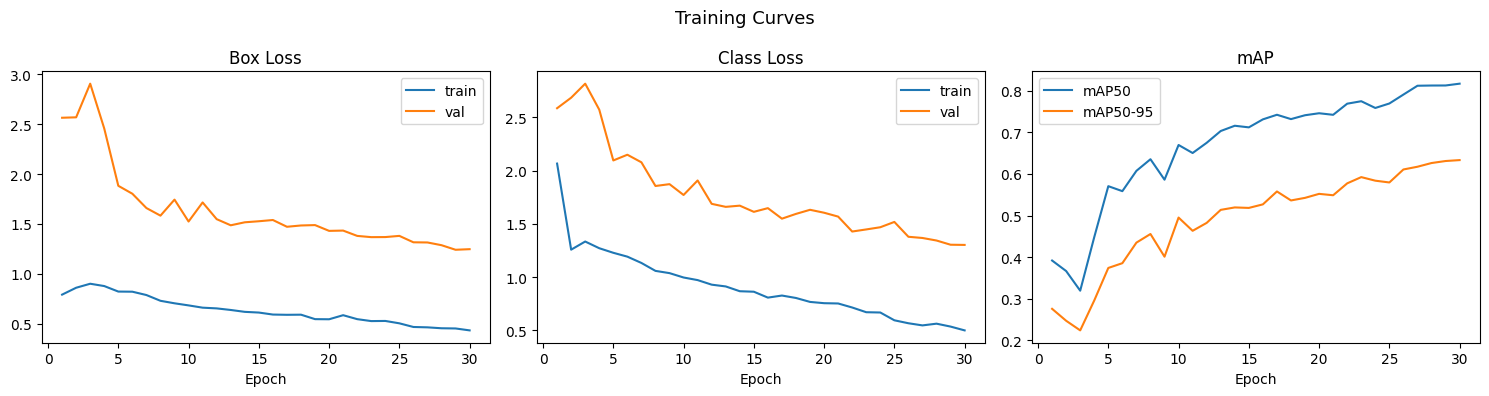

In [16]:
import pandas as pd

results_csv = RUN_DIR / "results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Training Curves", fontsize=13)

axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
axes[0].plot(df["epoch"], df["val/box_loss"], label="val")
axes[0].set_title("Box Loss")
axes[0].legend()
axes[0].set_xlabel("Epoch")

axes[1].plot(df["epoch"], df["train/cls_loss"], label="train")
axes[1].plot(df["epoch"], df["val/cls_loss"], label="val")
axes[1].set_title("Class Loss")
axes[1].legend()
axes[1].set_xlabel("Epoch")

axes[2].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
axes[2].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
axes[2].set_title("mAP")
axes[2].legend()
axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.show()


## Inference on Validation Images


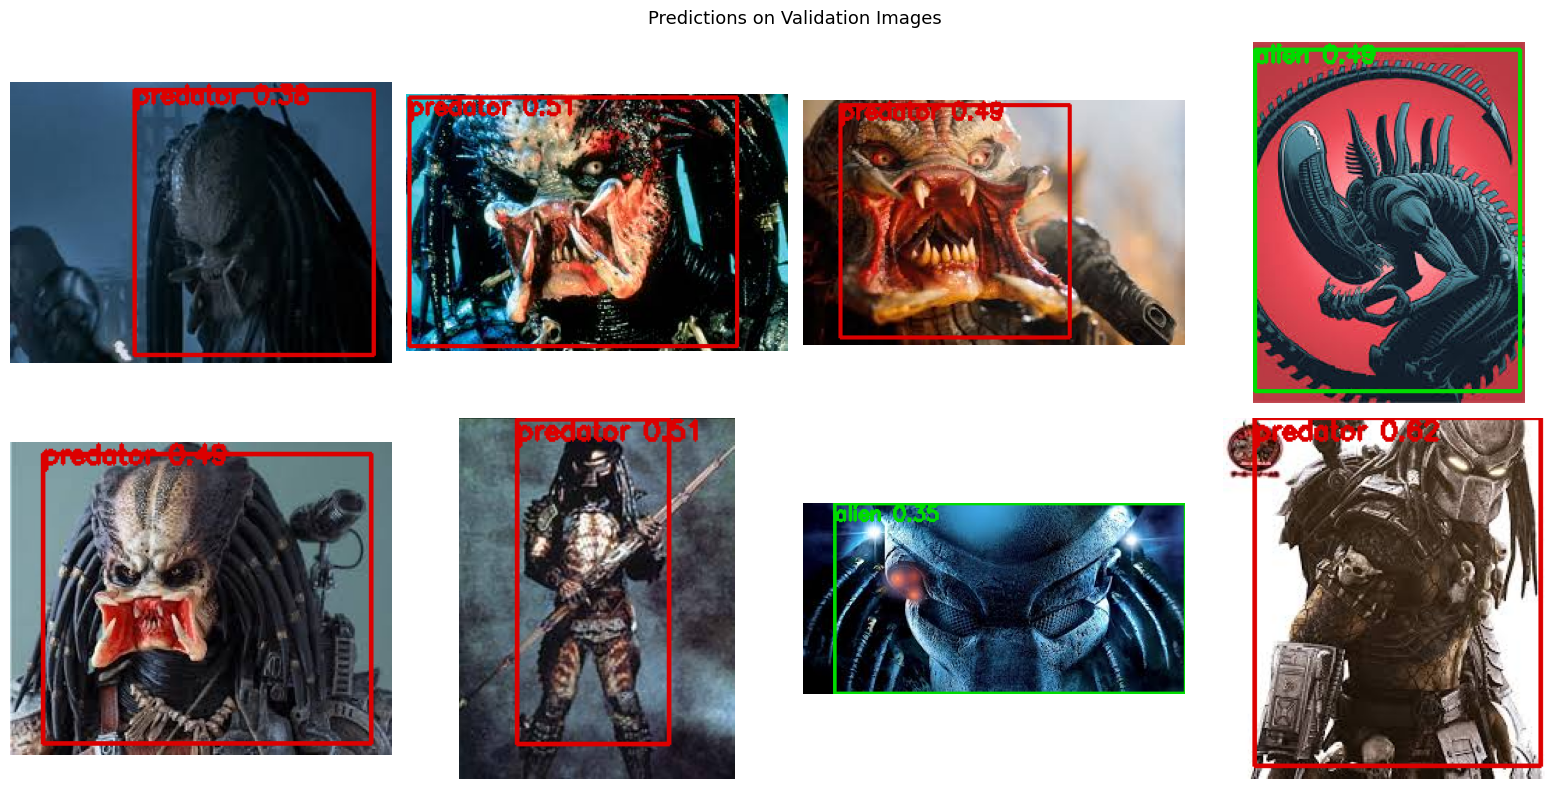

In [33]:
val_imgs = list((YOLO_ROOT / "images" / "val").glob("*.*"))
samples = random.sample(val_imgs, min(8, len(val_imgs)))

preds = trained_model.predict(samples, conf=0.20, imgsz=960, verbose=False)

COLOR = {"alien": (0, 220, 0), "predator": (220, 0, 0)}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Predictions on Validation Images", fontsize=13)

for ax, (img_path, result) in zip(axes.flat, zip(samples, preds)):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)

    for box in result.boxes:
        cls_id = int(box.cls)
        conf = float(box.conf)
        label = f"{CLASSES[cls_id]} {conf:.2f}"
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        color = COLOR[CLASSES[cls_id]]
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, label, (x1, max(y1 - 6, 14)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()


## Test on Screenshot


In [19]:
import os
import gdown
from pathlib import Path
from PIL import Image

os.makedirs("/kaggle/working/test", exist_ok=True)

file_id = "1rcyG4qYTGhlzUURZd_bhOOmKg4l6Ub4J"
url = f"https://drive.google.com/uc?id={file_id}"
img_path = Path("/kaggle/working/test/test2.png")

if img_path.exists():
    img_path.unlink()

gdown.download(url, str(img_path), quiet=False, fuzzy=True)

print("Existe:", img_path.exists())
print("Tamaño bytes:", img_path.stat().st_size)
print("PIL pudo leerla:", Image.open(img_path).format, Image.open(img_path).size)
print("OpenCV pudo leerla:", cv2.imread(str(img_path)) is not None)


Downloading...
From: https://drive.google.com/uc?id=1rcyG4qYTGhlzUURZd_bhOOmKg4l6Ub4J
To: /kaggle/working/test/test2.png
100%|██████████| 1.14M/1.14M [00:00<00:00, 133MB/s]

Existe: True
Tamaño bytes: 1142253
PIL pudo leerla: PNG (1305, 584)
OpenCV pudo leerla: True


Detections: 20


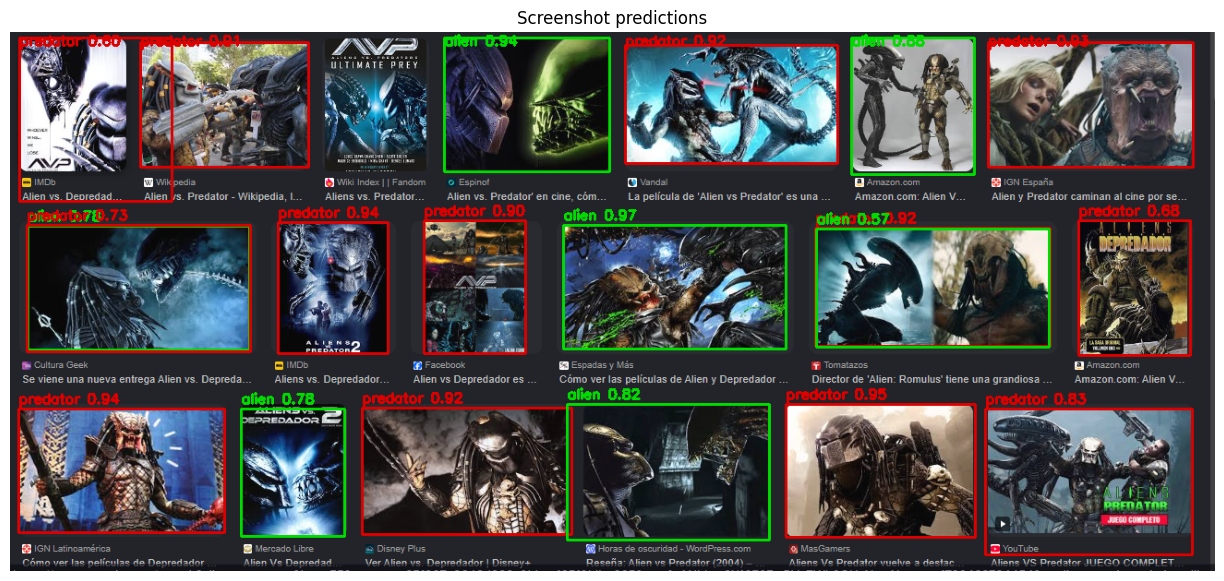

In [20]:
trained_model = YOLO(str(best_weights))

result = trained_model.predict(
    str(img_path),
    conf=0.45,
    iou=0.40,
    imgsz=1280,
    max_det=80,
    verbose=False,
)[0]

img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)

print(f"Detections: {len(result.boxes)}")
for box in result.boxes:
    cls_id = int(box.cls)
    conf = float(box.conf)
    label = f"{CLASSES[cls_id]} {conf:.2f}"
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    color = COLOR[CLASSES[cls_id]]
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    cv2.putText(img, label, (x1, max(y1 - 6, 14)), cv2.FONT_HERSHEY_SIMPLEX, 0.50, color, 2)

plt.figure(figsize=(18, 7))
plt.imshow(img)
plt.title("Screenshot predictions")
plt.axis("off")
plt.show()


## Important Note

This method produces **automatic pseudo-labels**, not real ground truth. It is better than full-image labels because boxes vary by image and synthetic collages teach YOLO to detect several objects in a scene.

For the most correct object detection dataset, the best method is still manual annotation with tools like CVAT, Label Studio, Roboflow, or LabelImg. A small manually labeled subset can also be used to improve or validate these pseudo-labels.
